In [1]:
# pip install soundfile numpy scipy matplotlib

In [2]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt
import soundfile as sf

# Advanced signal processing - Allpass and invertibility problems

## 1 Allpass filters and reverberators

### 1. Read example 5.7 and 5.9 in Manolakis and Ingle. In particular, pay attention to the two impulse responses (Fig. 5.26 and 5.32) and compare them.

The two impulse respones show that the reverberators echo the input signal at a period of $D$ samples and attenuates by a factor of $a$. The comb filter starts with an echo of amplitude 1 while the allpass filter starts with $-a$. The effect the two filters have on audio can be seen in the magnitude response, where the comb filter has periodic peaks while the allpass filter is flat, meaning that it prevents coloration as described in example 5.9.

### 2. Find a way of implementing the reverberators in MATLAB.

In [3]:
def comb_reverb(x, a, D):
    """
    Comb filter reverberator: y[n] = x[n] + a*y[n-D]
    System function: H(z) = 1 / (1 - a*z^(-D))
    """
    b = np.array([1.0])
    a_coeffs = np.zeros(D + 1)
    a_coeffs[0] = 1.0
    a_coeffs[D] = -a
    y = lfilter(b, a_coeffs, x)
    return y

def allpass_reverb(x, a, D):
    """
    Allpass reverberator: y[n] = a*y[n-D] -a*x[n] + x[n-D]
    System function: H(z) = (z^(-D) - a) / (1 - a*z^(-D))
    """
    b = np.zeros(D + 1)
    b[0] = -a
    b[D] = 1.0
    a_coeffs = np.zeros(D + 1)
    a_coeffs[0] = 1.0
    a_coeffs[D] = -a
    y = lfilter(b, a_coeffs, x)
    return y

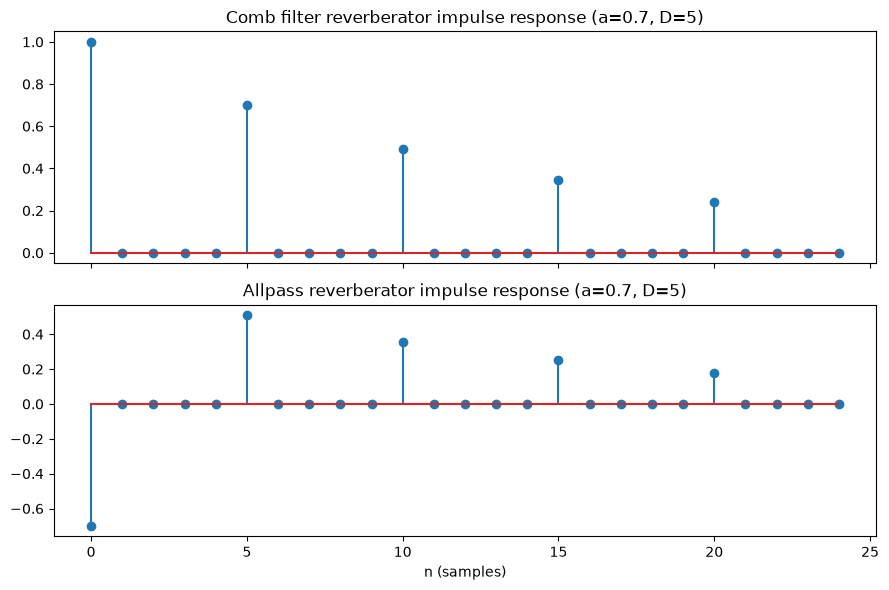

In [4]:
# same variable values as in example
a = 0.7
D = 5

N = 25
impulse = np.zeros(N)
impulse[0] = 1.0
 
h_comb = comb_reverb(impulse, a, D)
h_allpass = allpass_reverb(impulse, a, D)
 
fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].stem(h_comb)
axs[0].set_title(f"Comb filter reverberator impulse response (a={a}, D={D})")
axs[1].stem(h_allpass)
axs[1].set_title(f"Allpass reverberator impulse response (a={a}, D={D})")
axs[1].set_xlabel("n (samples)")
plt.tight_layout()
plt.savefig("impulse_responses.png", dpi=150)
plt.show()


### 3. Assume we will use the reverberators on a 48 kHz system. What are suitable values of a and D?

Example 2.8 says that D has to be a value that makes $\tau < 40 \text{ ms}$ to avoid echos, where $\tau = \frac{D}{F_s}$ is the delay. I assume that echos are not desired in this reverberator. A delay of $\tau = 20 \text{ ms}$ is chosen which gives a round-trip delay of
$$
D = 20 \text{ ms} \cdot 48 \text{ kHz} = 960 \text{ samples}
$$

The only requirement for the attenuation factor is that is has to uphold $-1 < a < 1$ to be stable. The books value of $a = 0.7$ can therefore be used.

### 4. On Brightspace you can find a short piece of music sampled at 48 kHz. Use wavread to load this into MATLAB and play it with audioplayer.

### 5. Run the music through the two reverb erators and listen to the output. Is it possible to tell the difference?

In [ ]:
fs = 48000
tau = 0.05
a = 0.7
D = int(tau * fs)

infile = "Music_sample_1(48kHz).wav"
x, fs_in = sf.read(infile)
assert fs_in == fs, f"Expected sample rate {fs}, but got {fs_in}"

y_comb = comb_reverb(x, a, D)
y_allpass = allpass_reverb(x, a, D)

sf.write("music_comb.wav", y_comb, fs)
sf.write("music_allpass.wav", y_allpass, fs)
print("Wrote music_comb.wav and music_allpass.wav")


Wrote music_comb.wav and music_allpass.wav


i dont hear anything man

## 2 Cascading all-pass filter
The transfer function of a 1st order all-pass filter is given by
$$
H_{AP}(z) = \frac{z^{-1} - p^*}{1 - pz^{-1}}
$$

### 1. Show that the cascade of two 1st order all-pass filters having complex conjugated poles, $p_{1} = p^*_{2}$ gives a second order all-pass filter with real coeffcients.

In [9]:
def first_order_allpass(p):
    """
    1st order all-pass filter:
    H(z) = (z^(-1) - p*) / (1 - p*z^(-1))
    """
    b = np.array([-p, 1.0])
    a_coeffs = np.array([1.0, -p])
    return b, a_coeffs

In [10]:
cascade_poles = [0.5 + 0.5j, 0.5 - 0.5j]
b1, a1 = first_order_allpass(cascade_poles[0])
b2, a2 = first_order_allpass(cascade_poles[1])
print("First order all-pass filter coefficients:")
print(f"Filter 1: b = {b1}, a = {a1}")
print(f"Filter 2: b = {b2}, a = {a2}")

# Combine the filters in cascade
b = np.convolve(b1, b2)
a = np.convolve(a1, a2)
print(f"Cascaded filter: b = {b}, a = {a}")


First order all-pass filter coefficients:
Filter 1: b = [-0.5-0.5j  1. +0.j ], a = [ 1. +0.j  -0.5-0.5j]
Filter 2: b = [-0.5+0.5j  1. +0.j ], a = [ 1. +0.j  -0.5+0.5j]
Cascaded filter: b = [ 0.5+0.j -1. +0.j  1. +0.j], a = [ 1. +0.j -1. +0.j  0.5+0.j]
